# Demo: Piglet and Value Iteration

This notebook demonstrates the four-file code structure:

```text
Code/
├── piglet.py
├── pig.py
├── value_iteration.py
└── analysis_helpers.py
```

The goal is to verify that:

1. `piglet.py` can run the Piglet game.
2. `value_iteration.py` solves the optimal win-probability equations.
3. `analysis_helpers.py` extracts validation results and article-style visualization data.
4. The numerical results align with the paper *Optimal Play of the Dice Game Pig*.


## 1. Import modules

The cell below tries both `Code/` and `code/` as module locations. This is useful if your local folder uses a capital `Code`, as in many Windows projects.

In [1]:
# Import modules
from pathlib import Path
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../')

from src.optimal_pig import piglet
from src.optimal_pig import pig
from src.optimal_pig import value_iteration_fun as vi
from src.optimal_pig import analysis_helpers as ah

print("Imported modules successfully.")

Imported modules successfully.


## 2. Run the games directly

This section verifies that the game simulators work independently of value iteration.

These simulations are random because the games involve coin flips or dice rolls. The random seed controls only the simulated game path, not the value-iteration solution.

In [2]:
# Piglet demo: target score 2, both players use a simple always-flip-until-win policy.
piglet_policy = piglet.make_always_flip_policy(target_score=2)

piglet_final = piglet.play_game(
    policy0=piglet_policy,
    policy1=piglet_policy,
    target_score=2,
    seed=1,
    first_player=0,
)

print("Piglet final state:")
print(piglet_final)

Piglet final state:
PigletState(scores=(2, 0), turn_total=0, current_player=0, winner=0)


## 3. Verify state-space definitions

The article uses the state

$(i,j,k),$


where:

- `i` is the current player's banked score,
- `j` is the opponent's banked score,
- `k` is the current turn total.

For target score \(G\), valid non-terminal states satisfy:

$0 \le i < G, \qquad 0 \le j < G, \qquad 0 \le k < G - i.$

In [3]:
piglet_spec_2 = piglet.make_spec(target_score=2)
print("Piglet target=2 state count:", vi.count_states(piglet_spec_2))

Piglet target=2 state count: 6


## 4. Solve Piglet goal=2 and validate exact values

The paper gives exact values for the six non-terminal Piglet states when the target score is 2:

$P_{0,0,0}=\frac47,\quad
P_{0,0,1}=\frac57,\quad
P_{0,1,0}=\frac25,\quad
P_{0,1,1}=\frac35,\quad
P_{1,0,0}=\frac45,\quad
P_{1,1,0}=\frac23.$


This is the strongest small-scale validation of the Bellman equations and the value-iteration implementation.

In [4]:
piglet_result = vi.value_iteration(
    piglet_spec_2,
    tol=1e-12,
    max_iterations=100_000,
    init_value=0.0,
    trace_states=ah.piglet_goal2_trace_states(),
    restricted_k = True, # 0 <= k < G-i
)

V_piglet = piglet_result["V"]
policy_piglet = piglet_result["policy"]

print("Converged:", piglet_result["converged"])
print("Iterations:", piglet_result["iterations"])

errors = ah.check_piglet_goal2_solution(V_piglet, atol=1e-10)
print("Exact-value errors:")
for state, err in errors.items():
    print(f"  {state}: {err:.3e}")

print("Computed vs exact:")
for state, exact in ah.piglet_goal2_exact_values().items():
    print(f"{state}: computed={V_piglet[state]:.12f}, exact={exact:.12f}")

print("Piglet exact-value validation passed.")

Converged: True
Iterations: 64
Exact-value errors:
  (0, 0, 0): 0.000e+00
  (0, 0, 1): 0.000e+00
  (0, 1, 0): 1.404e-12
  (0, 1, 1): 8.001e-13
  (1, 0, 0): 1.060e-12
  (1, 1, 0): 0.000e+00
Computed vs exact:
(0, 0, 0): computed=0.571428571429, exact=0.571428571429
(0, 0, 1): computed=0.714285714286, exact=0.714285714286
(0, 1, 0): computed=0.400000000001, exact=0.400000000000
(0, 1, 1): computed=0.600000000001, exact=0.600000000000
(1, 0, 0): computed=0.799999999999, exact=0.800000000000
(1, 1, 0): computed=0.666666666667, exact=0.666666666667
Piglet exact-value validation passed.


In [5]:
# Save output
import pickle

save = False

if save:
    with open("piglet_result.pkl", "wb") as f:
        pickle.dump(piglet_result, f)
    
    print("Saved piglet_result.pkl")

Saved piglet_result.pkl


## 5. Plot Piglet convergence data

This reproduces the mathematical object behind the paper's Piglet convergence figure: each curve is the sequence of value-iteration estimates for one state.

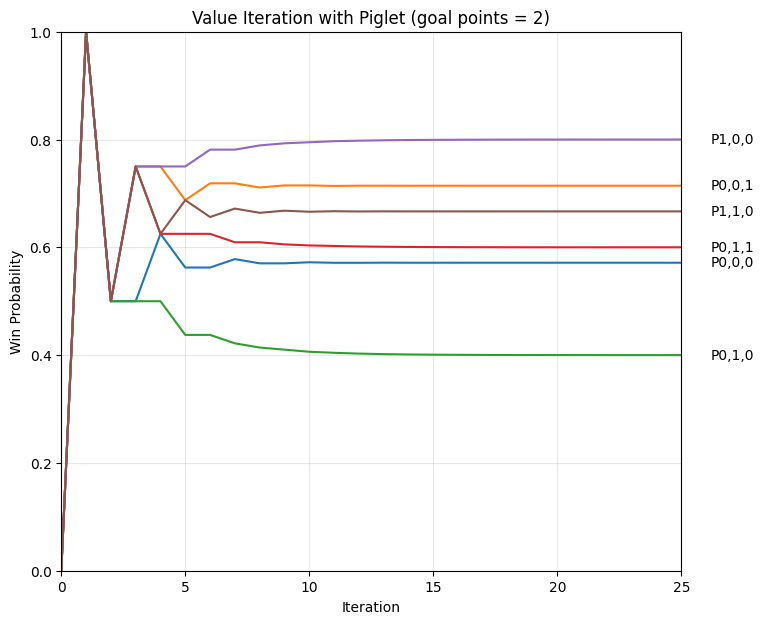

In [8]:
# controlling figure size
_, AX = plt.subplots(figsize=(8, 7)) 

# generating figure
fig2_data = ah.figure2_data_from_result(piglet_result)
ax = ah.plot_figure2_piglet_trace(fig2_data, 
                                  ax = AX)

# additional formatting
plt.xlim(0, 25)

labels = ['P0,0,0', 'P0,0,1', 'P0,1,0', 'P0,1,1', 'P1,0,0', 'P1,1,0']
lines = [line for line in ax.get_lines() if line.get_linestyle() != 'None']

for line, label in zip(lines, labels): # annotate each line at its right end
    x = 26 # line.get_xdata()[-1]  
    y = line.get_ydata()[-1]  
    ax.text(x + 0.2, y, label, va='center', fontsize=10) 

ax.legend().remove() # remove legend

# plot
plt.show()

## 6. Inspect the Piglet policy table

The policy table stores the optimal action at each state:

- `1` means continue: `flip` for Piglet or `roll` for Pig.
- `0` means `hold`.
- `-1` means invalid or terminal table entry.

For Piglet with target score 2, the paper states that the optimal policy is to keep flipping in every non-terminal state.

In [ ]:
restricted_k = True

print("Piglet policy table entries for valid states:")
for state in vi.iter_states(piglet_spec_2, restricted_k = restricted_k):
    action_code = policy_piglet[state]
    action_name = piglet_spec_2["continue_action"] if action_code == 1 else piglet_spec_2["hold_action"]
    print(f"state={state}, policy={action_code}, action={action_name}")

valid_codes = [policy_piglet[state] for state in vi.iter_states(piglet_spec_2, restricted_k = restricted_k)]
assert all(code == 1 for code in valid_codes)
print("Piglet target=2 policy check passed: all valid states choose flip.")

## 7. Use the solved Piglet policy in the actual game simulator

The value-iteration output is not random. However, once the solved policy is used to play an actual game, the game path is random because it depends on coin flips.

In [ ]:
piglet_optimal_policy = vi.optimal_policy_function(piglet_spec_2, V_piglet, restricted_k = True)

piglet_optimal_game = piglet.play_game(
    policy0=piglet_optimal_policy,
    policy1=piglet_optimal_policy,
    target_score=2,
    seed=123,
    first_player=0,
)

print("Piglet game using solved optimal policy:")
print(piglet_optimal_game)

## 8. Final checklist

If the notebook ran successfully, the following should be true:

1. Piglet and Pig can both run as games.
2. The state count for full Pig is 505000.
3. Piglet target=2 reproduces the exact values from the paper.
4. Piglet target=2 chooses `flip` in all valid states.